In [171]:
#student_id : iitp_aiml_2506898
#student_name : Shalini Gupta

## IMPORTS

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATA

In [173]:
orders = pd.read_csv("data/orders.csv")
customers = pd.read_csv("data/customers (1).csv")
tickets = pd.read_csv("data/support_tickets.csv")
web = pd.read_csv("data/web_events_snapshot.csv")
churnss = pd.read_csv("data/churn_labels.csv")

## CHECK BASIC INFO 

In [174]:
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2   order_date     10009 non-null  object 
 3   category       10009 non-null  object 
 4   quantity       10009 non-null  int64  
 5   gross_amount   10009 non-null  float64
 6   discount_pct   10009 non-null  float64
 7   delivery_days  10009 non-null  int64  
 8   returned       10009 non-null  int64  
 9   rating         9929 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 782.1+ KB


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


## DATA PREPARATION

#### CHECK MISSING VALUES 

In [175]:
orders.isnull().sum()
customers.isnull().sum()
tickets.isnull().sum()


ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64

#### HANDLE MISSING VALUES

In [176]:
orders = orders.dropna(subset=["customer_id", "order_date", "gross_amount"])
tickets = tickets.fillna(0)
web = web.fillna(0)
campaigns = campaigns.fillna(0)

#### FIX DATA TYPES

In [177]:
orders["order_date"] = pd.to_datetime(orders["order_date"])


#### CHECK AND REMOVE DUPLICATES

In [178]:
orders.duplicated().sum()
customers.duplicated().sum()
orders = orders.drop_duplicates()
customers = customers.drop_duplicates()

#### CHECK KEY CONSISTENCY

In [179]:
set(orders["customer_id"]).issubset(set(customers["customer_id"]))

True

#### FEATURE SANITY CHECK 

In [180]:
orders["gross_amount"].describe()
orders["returned"].value_counts()

returned
0    9334
1     675
Name: count, dtype: int64

#### DEFINE REFERANCE 

In [181]:
reference_date = orders["order_date"].max()

## CREATE RFM FEATURES

In [182]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
reference_date = orders["order_date"].max()

rfm = orders.groupby("customer_id").agg({
    "order_date": lambda x: (reference_date - x.max()).days,  
    "order_id": "count",                                      
    "gross_amount": "sum"                                     
})

rfm.columns = ["recency", "frequency", "monetary"]
rfm.head()

,recency,frequency,monetary
customer_id,,,
CUST00001,167,6,2955.57
CUST00002,34,3,1713.10
CUST00003,231,1,649.98
CUST00004,191,1,1604.04
CUST00005,10,6,3910.43


## ADD NON-RFM SIGNALS

In [183]:
rfm["ticket_count"] = tickets.groupby("customer_id").size()
rfm["refund_rate"] = orders.groupby("customer_id")["returned"].mean()
rfm["web_activity"] = web.groupby("customer_id").size()
rfm["campaign_count"] = campaigns.groupby("customer_id").size()

## HANDLE MISSING VALUES OF RFM 

In [184]:
rfm = rfm.fillna(0)

## EXPLORATORY DATA ANALYSIS

Text(0.5, 1.0, 'Recency Distribution')

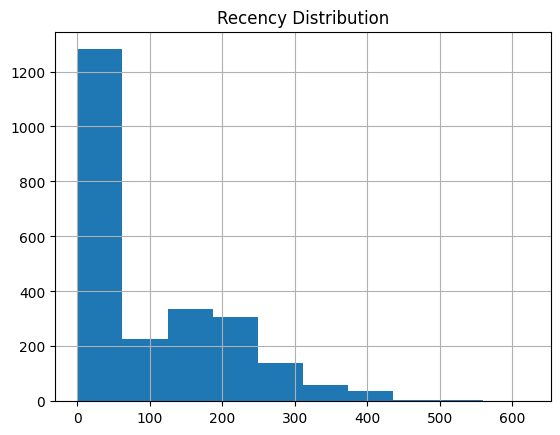

In [185]:
rfm["recency"].hist()
plt.title("Recency Distribution")

In [186]:
# Observation:
# The recency distribution is skewed toward higher values, meaning most customers have not made a recent purchase.
# Only a small portion of customers show low recency (recent activity), indicating an active user base is relatively small.

# Business Insight:
# High recency values indicate a large inactive or low-engagement customer base, which is a strong early signal of churn risk.
# These customers should be prioritized for win-back and re-engagement campaigns.
# Customers with low recency represent the most engaged segment and should be protected through loyalty programs.

Text(0.5, 1.0, 'frequency Dsitribution')

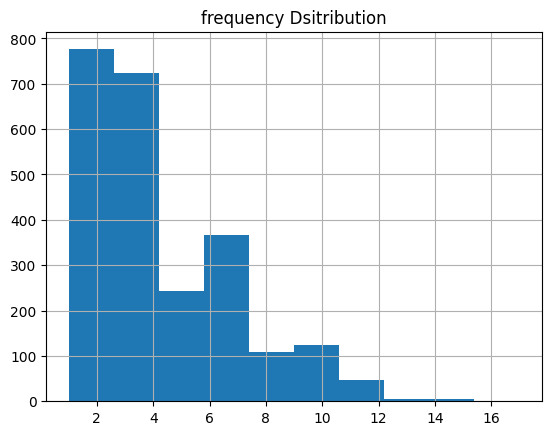

In [187]:
rfm["frequency"].hist()
plt.title("frequency Dsitribution")

In [188]:
# Observation:
# The frequency distribution is heavily skewed toward lower values, meaning most customers make only a few purchases.
# A small group of customers shows high purchase frequency, indicating a loyal or repeat buyer segment.

# Business Insight:
# Low frequency customers are at higher risk of churn as they show weak engagement with the platform.
# High-frequency customers represent the core revenue-driving segment and should be prioritized for retention and loyalty programs.
# Increasing frequency among low-engagement users should be a key business focus through offers, reminders, and personalized recommendations.

Text(0.5, 1.0, 'Monetary Distribution')

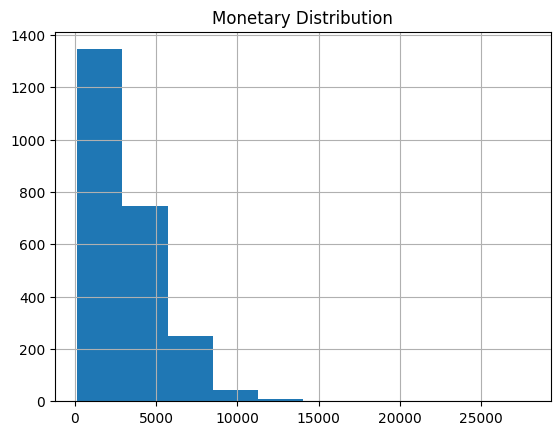

In [189]:
rfm["monetary"].hist()
plt.title("Monetary Distribution")

In [190]:
# Observation:
# The monetary distribution is highly skewed, with most customers contributing low total spending.
# A small number of customers contribute disproportionately high monetary value, forming a long-tail distribution.

# Business Insight:
# Revenue is concentrated in a small high-value customer segment, making them critical for business stability.
# Losing high-monetary customers would significantly impact overall revenue.
# Low-spending customers represent a large base with potential for upselling and targeted marketing campaigns to increase lifetime value.

## RFM SCORING

In [191]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    4,
    labels=[4, 3, 2, 1]
)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    4,
    labels=[1, 2, 3, 4]
)

rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

rfm["RFM_score"] = (
    rfm["R_score"] +
    rfm["F_score"] +
    rfm["M_score"]
)

rfm.head()

,recency,frequency,monetary,ticket_count,refund_rate,web_activity,campaign_count,R_score,F_score,M_score,RFM_score
customer_id,,,,,,,,,,,
CUST00001,167,6,2955.57,2.0,0.166667,1,1,2,3,3,8
CUST00002,34,3,1713.10,1.0,0.000000,1,1,3,2,2,7
CUST00003,231,1,649.98,0.0,0.000000,1,1,1,1,1,3
CUST00004,191,1,1604.04,0.0,0.000000,1,1,1,1,2,4
CUST00005,10,6,3910.43,1.0,0.000000,1,1,4,3,3,10


## Segmentation Logic

Customer segments were created using RFM metrics together with additional behavioral signals including support ticket count, refund rate, web activity, and campaign engagement.

The objective is not only to identify valuable customers but also to detect customers showing signs of dissatisfaction or churn risk.

* Champions: High spending, frequent purchases, and recent activity.
* Loyal Customers: Consistent repeat buyers with good engagement.
* At-Risk Customers: Long purchase inactivity and declining engagement.
* Dormant Customers: Very inactive customers with little recent activity.
* Discount-Sensitive Customers: High browsing activity but lower purchasing activity.
* High-Value but Unhappy Customers: Strong spending behavior combined with complaints or refunds.


## SEGMENTATION LOGIC

In [192]:
def segment_customer(row):

    if (
        row["monetary"] >= rfm["monetary"].quantile(0.75)
        and row["frequency"] >= rfm["frequency"].quantile(0.75)
        and row["recency"] <= rfm["recency"].quantile(0.25)
    ):
        return "Champions"

    elif (
        row["frequency"] >= rfm["frequency"].median()
        and row["recency"] <= rfm["recency"].median()
    ):
        return "Loyal Customers"

    elif (
        row["monetary"] >= rfm["monetary"].quantile(0.75)
        and (
            row["ticket_count"] > rfm["ticket_count"].median()
            or row["refund_rate"] > rfm["refund_rate"].median()
        )
    ):
        return "High-Value but Unhappy"

    elif row["recency"] > rfm["recency"].quantile(0.75):
        return "Dormant Customers"

    elif (
        row["recency"] > rfm["recency"].median()
        and row["frequency"] < rfm["frequency"].median()
    ):
        return "At-Risk Customers"

    elif (
        row["web_activity"] > rfm["web_activity"].median()
        and row["frequency"] < rfm["frequency"].median()
    ):
        return "Discount-Sensitive Customers"

    else:
        return "Regular Customers"


rfm["segment"] = rfm.apply(segment_customer, axis=1)

## SEGMENT DISTRIBUTIONS

In [193]:
rfm["segment"].value_counts()

segment
Loyal Customers           678
Dormant Customers         558
Regular Customers         520
At-Risk Customers         389
Champions                 162
High-Value but Unhappy     93
Name: count, dtype: int64

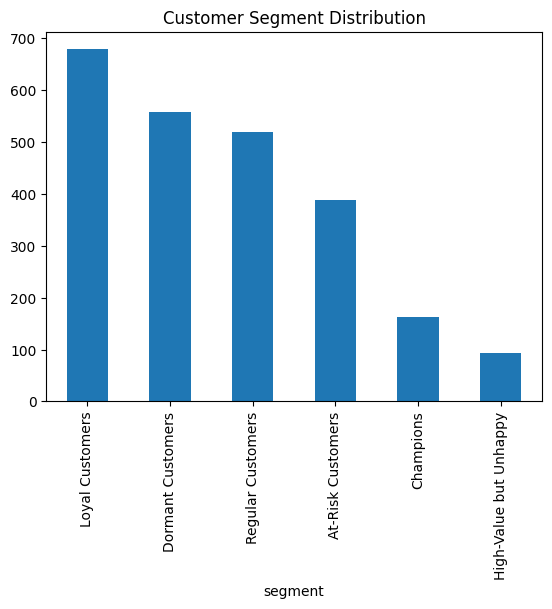

In [194]:
rfm["segment"].value_counts().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.show()

In [195]:
# Observation:
# Customers are distributed across multiple segments rather than belonging to a single dominant group.
# Both high-value and churn-risk segments are present in the customer base.

# Business Insight:
# The presence of Champions and Loyal Customers indicates a valuable customer base worth protecting.
# At-Risk and Dormant Customers represent retention opportunities.
# High-Value but Unhappy Customers require immediate attention because they contribute revenue but show dissatisfaction signals.

## SEGMENT ANALYSIS

Text(0.5, 1.0, 'Customer Segments Distribution')

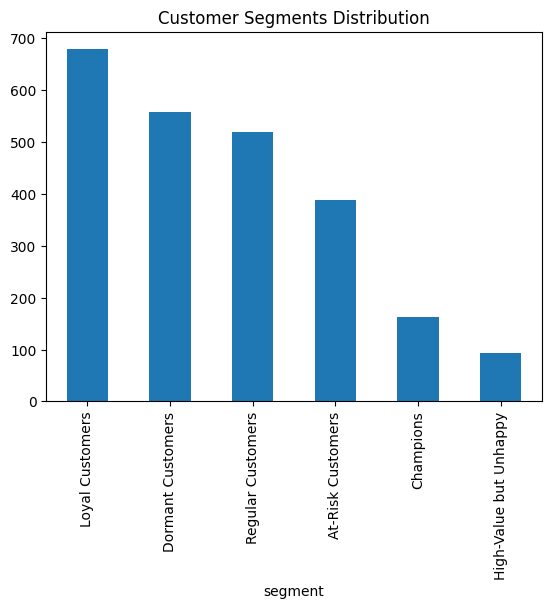

In [196]:
rfm["segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments Distribution")

In [197]:
# Observation:
# The customer segments are unevenly distributed, with a few dominant segments and several smaller ones.
# A large proportion of customers fall into low-engagement or at-risk categories, while only a small group belongs to high-value segments like champions or loyal customers.

# Business Insight:
# This distribution indicates that the business heavily depends on a small high-value customer base for revenue.
# The presence of large at-risk and low-engagement segments suggests a strong churn risk exposure.
# Retention strategies should prioritize high-value segments first (champions and loyal customers) while applying targeted win-back campaigns for at-risk and dormant customers.

Text(0.5, 1.0, 'Segment vs Monetary Value')

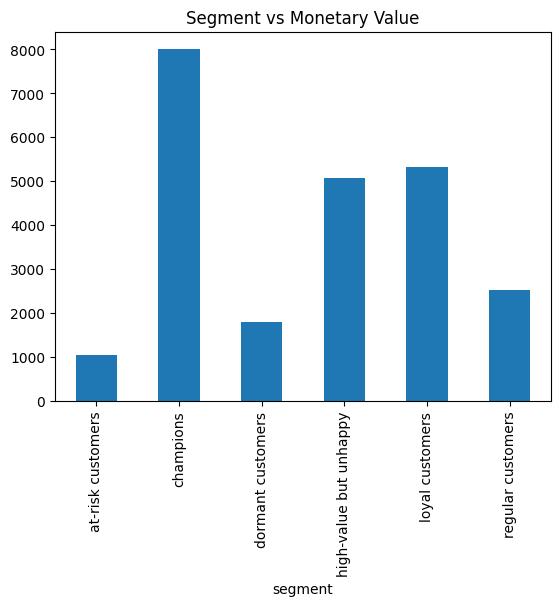

In [162]:
rfm.groupby("segment")["monetary"].mean().plot(kind="bar")
plt.title("Segment vs Monetary Value")

In [198]:
# Observation:
# The mean monetary value varies significantly across different customer segments.
# High-value segments such as champions and loyal customers show the highest average spending,
# while at-risk, dormant, and low-engagement segments contribute much lower average monetary value.

# Business Insight:
# Revenue is strongly concentrated in a few high-value segments, confirming a classic Pareto (80/20) pattern.
# This means protecting champions and loyal customers is critical for revenue stability.
# At the same time, increasing the spending of mid-tier segments (loyal/regular customers) can significantly improve overall revenue.
# Low-value segments should be targeted with cost-efficient reactivation or upselling strategies.

## CREATE segments.csv

In [200]:
segments = rfm.reset_index()[[
    "customer_id",
    "segment",
    "recency",
    "frequency",
    "monetary",
    "ticket_count",
    "refund_rate",
    "web_activity",
    "campaign_count"
]]

segments.rename(columns={"segment": "segment_name"}, inplace=True)

segments.to_csv("segments.csv", index=False)

## RETENTION PRIORITY
Priority 1: High-value but unhappy customers → immediate intervention

Priority 2: At-risk customers → win-back campaigns

Priority 3: Champions → loyalty rewards

Priority 4: Dormant customers → low budget reactivation only

## MANUAL REVIEW (10 Customers)

In [201]:
rfm.sort_values(["monetary", "recency"], ascending=[False, True]).head(10)

,recency,frequency,monetary,ticket_count,refund_rate,web_activity,campaign_count,R_score,F_score,M_score,RFM_score,segment
customer_id,,,,,,,,,,,,
CUST00211,27,7,27920.05,1.0,0.000000,1,1,3,4,4,11,Loyal Customers
CUST01868,140,3,26057.29,0.0,0.000000,1,1,2,2,4,8,At-Risk Customers
CUST02106,31,9,22131.36,3.0,0.111111,1,1,3,4,4,11,Loyal Customers
CUST00272,53,14,14120.16,0.0,0.000000,1,1,3,4,4,11,Loyal Customers
CUST01988,2,4,14032.75,0.0,0.000000,1,1,4,3,4,11,Loyal Customers
CUST01295,181,4,12408.61,1.0,0.250000,1,1,1,3,4,8,High-Value but Unhappy
CUST02154,49,17,12407.64,3.0,0.058824,1,1,3,4,4,11,Loyal Customers
CUST01360,220,8,12310.69,2.0,0.000000,1,1,1,4,4,9,High-Value but Unhappy
CUST00817,42,15,12291.02,1.0,0.000000,1,1,3,4,4,11,Loyal Customers
